In [24]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


In [25]:
# Importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix

In [26]:
# Load the dataset

# test = pd.read_csv('test.csv')
df_train = pd.read_csv('train.csv')

In [27]:
# Create copies of both data sets

# df_test_copy = df_test.copy()
df_train_copy = df_train.copy()

In [28]:
# Display the shape of the DataFrame
print("\nShape:")
print(df_train.shape)


Shape:
(58592, 44)


In [29]:
# Display all columns
pd.set_option('display.max_columns',  None )

In [30]:
# Display the first few rows
print("Head of the DataFrame:")
df_train.head()


Head of the DataFrame:


,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim
0,ID00001,0.515874,0.05,0.644231,C1,4990,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
1,ID00002,0.672619,0.02,0.375000,C2,27003,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
2,ID00003,0.841110,0.02,0.384615,C3,4076,1,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2,No,No,No,Yes,No,Drum,796,3,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0,0
3,ID00004,0.900277,0.11,0.432692,C4,21622,1,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2,Yes,Yes,No,Yes,Yes,Drum,1197,4,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2,0
4,ID00005,0.596403,0.11,0.634615,C5,34738,2,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2,No,No,No,No,Yes,Drum,999,3,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2,0


In [31]:
# Display DataFrame information
print("\nDataFrame Info:")
df_train.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 44 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58592 non-null  object 
 1   policy_tenure                     58592 non-null  float64
 2   age_of_car                        58592 non-null  float64
 3   age_of_policyholder               58592 non-null  float64
 4   area_cluster                      58592 non-null  object 
 5   population_density                58592 non-null  int64  
 6   make                              58592 non-null  int64  
 7   segment                           58592 non-null  object 
 8   model                             58592 non-null  object 
 9   fuel_type                         58592 non-null  object 
 10  max_torque                        58592 non-null  object 
 11  max_power                         58592 non-null  

In [32]:
# Display summary statistics
print("\nDataFrame Describe:")
df_train.describe()


DataFrame Describe:


,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating,is_claim
count,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.000000,58592.00000,58592.000000,58592.000000,58592.000000
mean,0.611246,0.069424,0.469420,18826.858667,1.763722,3.137066,1162.355851,3.626963,5.245443,4.852893,3850.476891,1672.233667,1553.33537,1385.276813,1.759950,0.063968
std,0.414156,0.056721,0.122886,17660.174792,1.136988,1.832641,266.304786,0.483616,0.430353,0.228061,311.457119,112.089135,79.62227,212.423085,1.389576,0.244698
min,0.002735,0.000000,0.288462,290.000000,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.00000,1051.000000,0.000000,0.000000
25%,0.210250,0.020000,0.365385,6112.000000,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.00000,1185.000000,0.000000,0.000000
50%,0.573792,0.060000,0.451923,8794.000000,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.00000,1335.000000,2.000000,0.000000
75%,1.039104,0.110000,0.548077,27003.000000,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.00000,1510.000000,3.000000,0.000000
max,1.396641,1.000000,1.000000,73430.000000,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.00000,1720.000000,5.000000,1.000000


In [33]:
# Display column names
print("\nColumn Names:")
print(df_train.columns)


Column Names:
Index(['policy_id', 'policy_tenure', 'age_of_car', 'age_of_policyholder',
       'area_cluster', 'population_density', 'make', 'segment', 'model',
       'fuel_type', 'max_torque', 'max_power', 'engine_type', 'airbags',
       'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
       'is_parking_camera', 'rear_brakes_type', 'displacement', 'cylinder',
       'transmission_type', 'gear_box', 'steering_type', 'turning_radius',
       'length', 'width', 'height', 'gross_weight', 'is_front_fog_lights',
       'is_rear_window_wiper', 'is_rear_window_washer',
       'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks',
       'is_central_locking', 'is_power_steering',
       'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
       'is_ecw', 'is_speed_alert', 'ncap_rating', 'is_claim'],
      dtype='object')


In [34]:
# Count null values in each column
print("\nNull Value Counts:")
print(df_train.isnull().sum())



Null Value Counts:
policy_id                           0
policy_tenure                       0
age_of_car                          0
age_of_policyholder                 0
area_cluster                        0
population_density                  0
make                                0
segment                             0
model                               0
fuel_type                           0
max_torque                          0
max_power                           0
engine_type                         0
airbags                             0
is_esc                              0
is_adjustable_steering              0
is_tpms                             0
is_parking_sensors                  0
is_parking_camera                   0
rear_brakes_type                    0
displacement                        0
cylinder                            0
transmission_type                   0
gear_box                            0
steering_type                       0
turning_radius                

In [35]:
# Count duplicated rows
print("\nDuplicated Rows Count:")
print(df_train.duplicated().sum())


Duplicated Rows Count:
0


In [36]:
# Count the different classes in the target variable
class_counts = df_train['is_claim'].value_counts()
print(class_counts)

is_claim
0    54844
1     3748
Name: count, dtype: int64


In [37]:
# Calculate the imbalance ratio
imbalance_ratio = class_counts[0] / class_counts[1]

print("Imbalance Ratio (Class 0 to Class 1): {:.2f}".format(imbalance_ratio))

Imbalance Ratio (Class 0 to Class 1): 14.63


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns


def create_simple_plot(data, x_col):
  # 1. Set the size of the chart window
  plt.figure(figsize=(8, 5))

  # 2. Draw the bar chart (countplot)
  sns.countplot(data=data, x=x_col)

  # 3. Add a simple title
  plt.title("Data Breakdown")

  # 4. Display the chart on the screen
  plt.show()

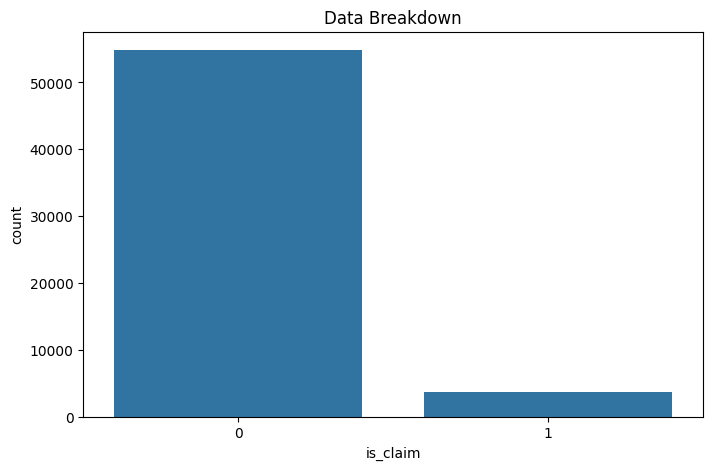

In [43]:
create_simple_plot(df_train, "is_claim")

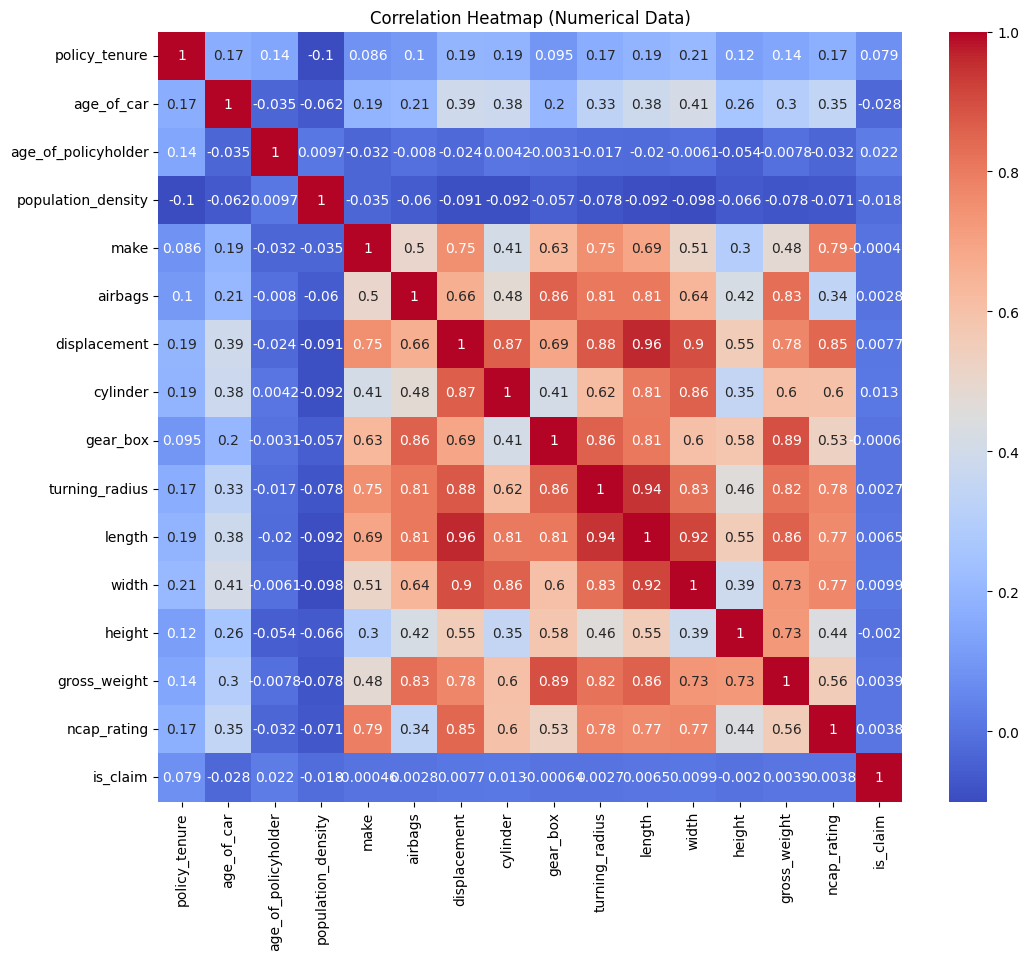

In [44]:
def plot_heatmap_numerical(data):
    # Select only numerical columns from the DataFrame
    numerical_data = data.select_dtypes(include=['number'])

    # Compute the correlation matrix for numerical data
    corr_matrix = numerical_data.corr()

    # Create the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap (Numerical Data)')
    plt.show()

# Example usage:
plot_heatmap_numerical(df_train)

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Custom Neon Colors (Optional to use)
neon_palette = ["#faeb2c", "#f52789", "#e900ff", "#1685f8", "#3d144c"]


# 2. Histogram (Shows the distribution of a single number column)
def plot_histogram(data, column):
  plt.figure(figsize=(8, 6))
  sns.histplot(data[column], kde=True)
  plt.title(f'Histogram of {column}')
  plt.show()


# 3. Simple Box Plot for ONE column (Instead of a complicated multi-grid)
def plot_boxplot(data, column):
  plt.figure(figsize=(8, 6))
  sns.boxplot(data=data, x=column)
  plt.title(f'Box Plot of {column}')
  plt.show()


# 4. Bar Chart (Counts items in a category column)
def plot_bar_chart(data, column):
  plt.figure(figsize=(8, 6))
  sns.countplot(x=column, data=data, palette=neon_palette)
  plt.title(f'Bar Chart of {column}')
  plt.xticks(rotation=45)
  plt.show()


# 5. Scatter Plot (Compares two number columns against each other)
def plot_scatter(data, x_column, y_column):
  plt.figure(figsize=(8, 6))
  sns.scatterplot(x=x_column, y=y_column, data=data)
  plt.title(f'Scatter Plot: {x_column} vs {y_column}')
  plt.show()


# 6. Pair Plot (Compares multiple columns in a grid of dots)
def plot_pairplot(data, columns):
  sns.pairplot(data[columns])
  plt.show()


# 7. Violin Plot (Shows how a number spreads across categories)
def plot_violinplot(data, x_column, y_column):
  plt.figure(figsize=(8, 6))
  sns.violinplot(x=x_column, y=y_column, data=data)
  plt.title(f'Violin Plot: {x_column} vs {y_column}')
  plt.xticks(rotation=45)
  plt.show()


# 8. Grouped Bar Chart (Compares a category split by a second category)
def plot_stackedbar(data, x_column, hue_column):
  plt.figure(figsize=(10, 6))
  sns.countplot(x=x_column, hue=hue_column, data=data, palette=neon_palette)
  plt.title(f'Grouped Bar Chart: {x_column} by {hue_column}')
  plt.xticks(rotation=45)
  plt.show()

1. Displaying Bar Chart...


/tmp/ipykernel_654/2785082862.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=data, palette=neon_palette)
/tmp/ipykernel_654/2785082862.py:27: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(x=column, data=data, palette=neon_palette)


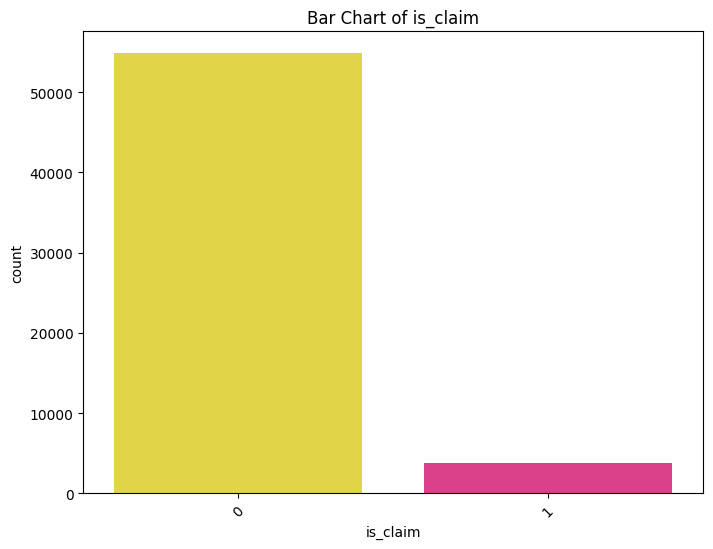

2. Displaying Histogram...


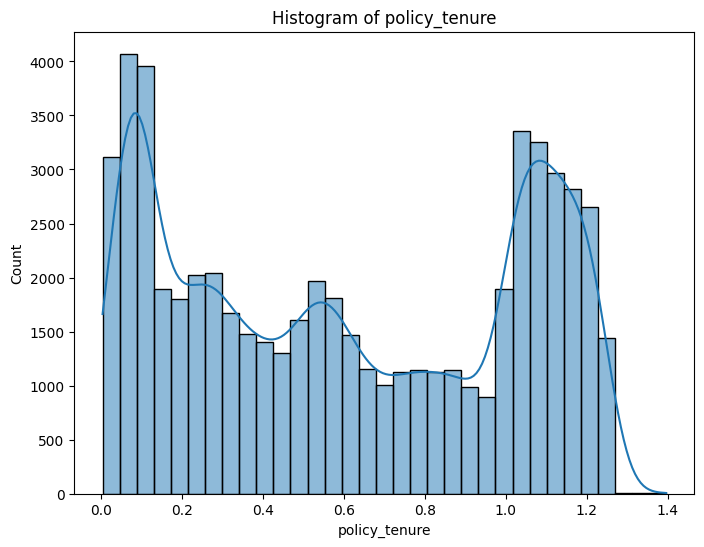

3. Displaying Box Plot...


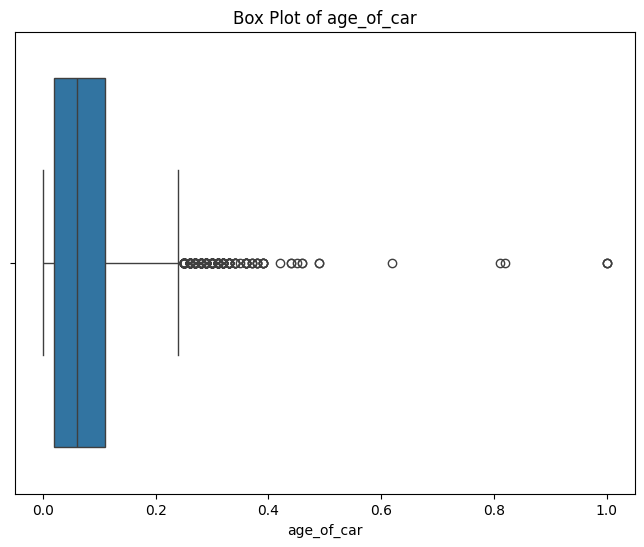

4. Displaying Scatter Plot...


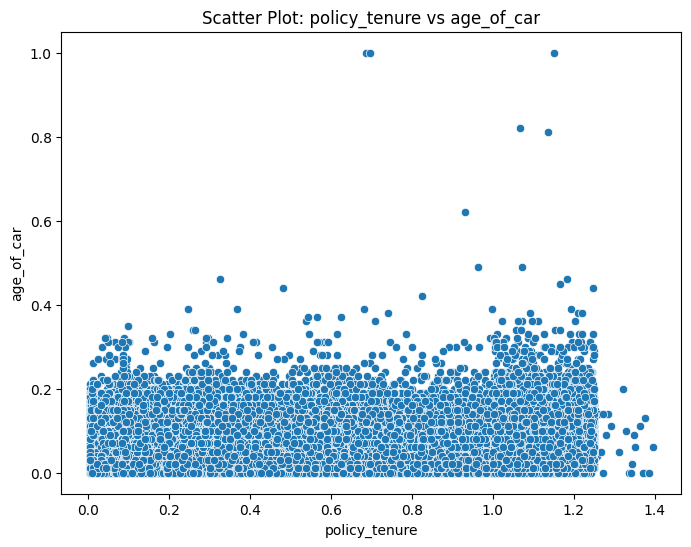

5. Displaying Grouped Bar Chart...


/tmp/ipykernel_654/2785082862.py:59: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.countplot(x=x_column, hue=hue_column, data=data, palette=neon_palette)


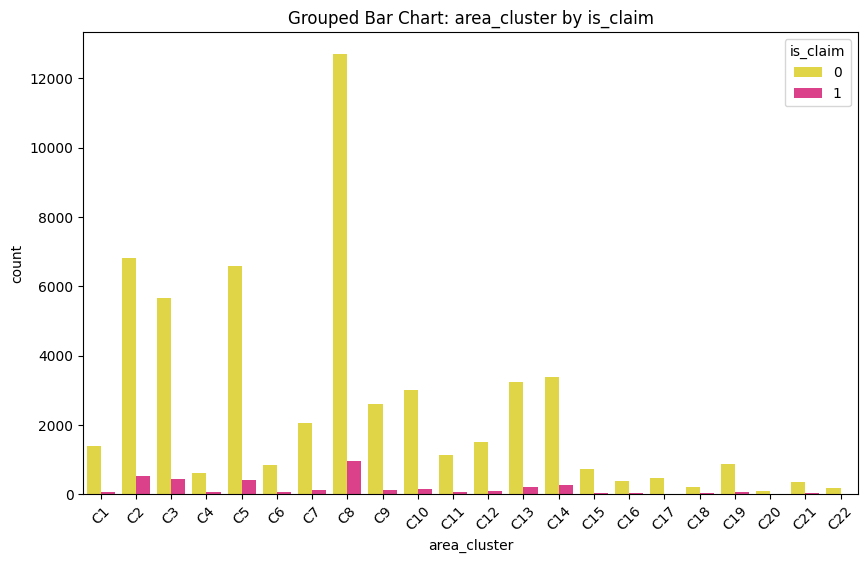

In [50]:
# --- RUN ALL PLOTS IN ONE CELL ---

# 1. Bar Chart of your target column (is_claim)
print("1. Displaying Bar Chart...")
plot_bar_chart(df_train, "is_claim")

# 2. Histogram of policy tenure distribution
print("2. Displaying Histogram...")
plot_histogram(df_train, "policy_tenure")

# 3. Box Plot to check for outliers in car age
print("3. Displaying Box Plot...")
plot_boxplot(df_train, "age_of_car")

# 4. Scatter Plot comparing policy tenure against car age
print("4. Displaying Scatter Plot...")
plot_scatter(df_train, "policy_tenure", "age_of_car")

# 5. Grouped Bar Chart comparing area cluster by claims
print("5. Displaying Grouped Bar Chart...")
plot_stackedbar(df_train, "area_cluster", "is_claim")

/tmp/ipykernel_654/2785082862.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=data, palette=neon_palette)
/tmp/ipykernel_654/2785082862.py:27: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(x=column, data=data, palette=neon_palette)


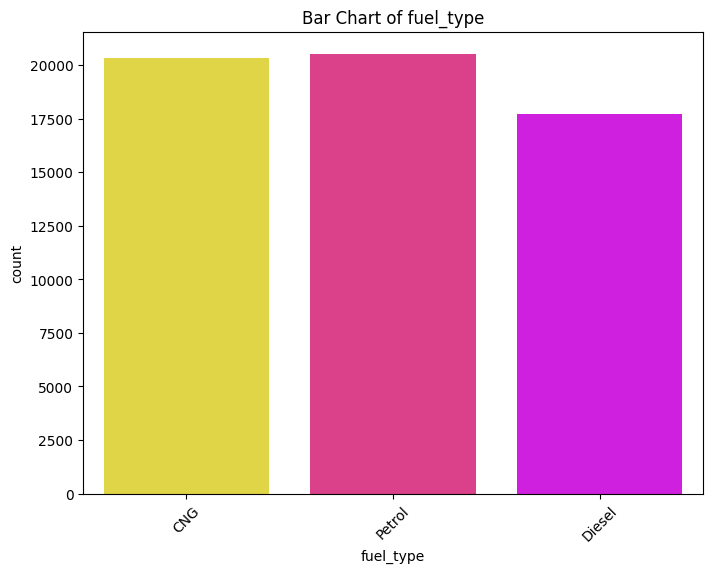

In [52]:
# Count plot for fuel_type
plot_bar_chart(df_train, 'fuel_type')

/tmp/ipykernel_654/2785082862.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=data, palette=neon_palette)
/tmp/ipykernel_654/2785082862.py:27: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=column, data=data, palette=neon_palette)


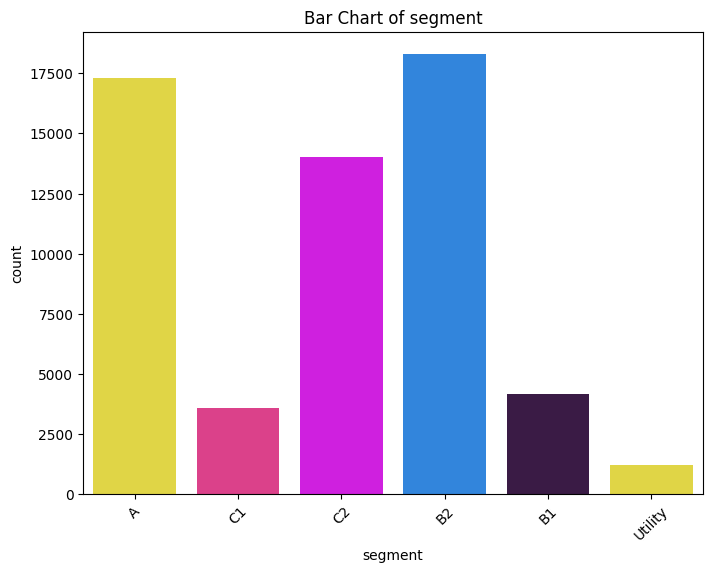

In [53]:
# Count plot for segment
plot_bar_chart(df_train, 'segment')

/tmp/ipykernel_654/2785082862.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=data, palette=neon_palette)
/tmp/ipykernel_654/2785082862.py:27: UserWarning: 
The palette list has fewer values (5) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=column, data=data, palette=neon_palette)


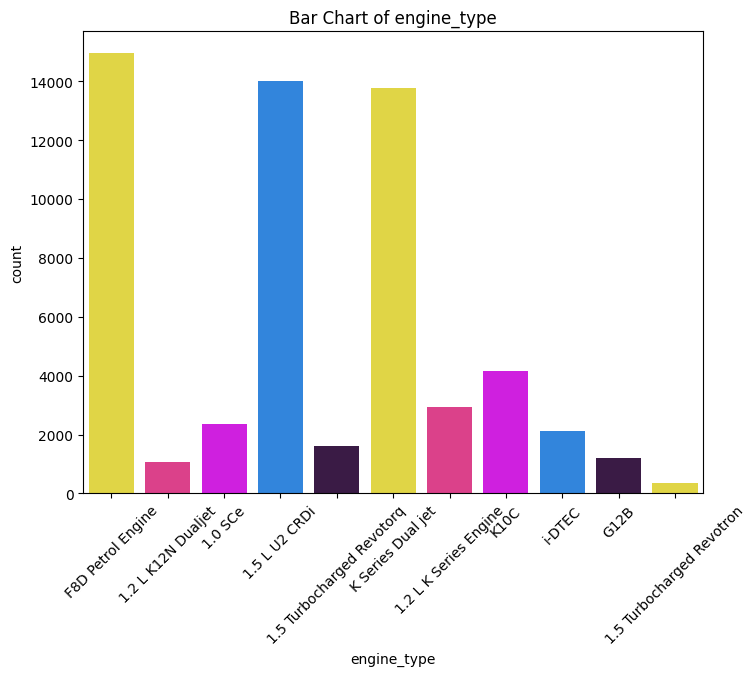

In [54]:
# Count plot for engine_type
plot_bar_chart(df_train, 'engine_type')

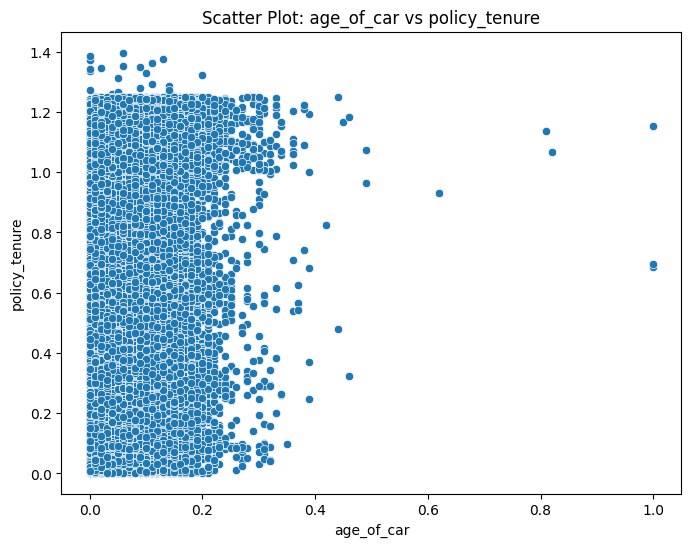

In [55]:
plot_scatter(df_train, 'age_of_car', 'policy_tenure')

In [56]:
#drop policy_id
df_train.drop('policy_id', axis=1, inplace=True)

# Data Preprocessing — Fixing & Preparing

In [57]:
# List of columns with "Yes" and "No" values
binary_columns = [
    'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors',
    'is_parking_camera', 'is_front_fog_lights', 'is_rear_window_wiper',
    'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist',
    'is_power_door_locks', 'is_central_locking', 'is_power_steering',
    'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror',
    'is_ecw', 'is_speed_alert'
]

# Map "Yes" to 1 and "No" to 0 for the specified columns
for col in binary_columns:
    df_train[col] = df_train[col].map({'Yes': 1, 'No': 0})

**Converting every text value liek yes or no to 0 or 1**

In [58]:
# Identify categorical columns
categorical_cols = df_train.select_dtypes(include=['object']).columns

# Perform one-hot encoding
df_encoded = pd.get_dummies(df_train, columns=categorical_cols)

# Check the resulting DataFrame
df_encoded.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58592 entries, 0 to 58591
Data columns (total 111 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    policy_tenure                          float64
 1    age_of_car                             float64
 2    age_of_policyholder                    float64
 3    population_density                     int64  
 4    make                                   int64  
 5    airbags                                int64  
 6    is_esc                                 int64  
 7    is_adjustable_steering                 int64  
 8    is_tpms                                int64  
 9    is_parking_sensors                     int64  
 10   is_parking_camera                      int64  
 11   displacement                           int64  
 12   cylinder                               int64  
 13   gear_box                               int64  
 14   turning_radius                      

In [59]:
#Check for null values
df_train.isnull().sum()

,0
policy_tenure,0
age_of_car,0
age_of_policyholder,0
area_cluster,0
population_density,0
make,0
segment,0
model,0
fuel_type,0
max_torque,0


In [60]:
# Check the data
df_encoded.head()

,policy_tenure,age_of_car,age_of_policyholder,population_density,make,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,is_claim,area_cluster_C1,area_cluster_C10,area_cluster_C11,area_cluster_C12,area_cluster_C13,area_cluster_C14,area_cluster_C15,area_cluster_C16,area_cluster_C17,area_cluster_C18,area_cluster_C19,area_cluster_C2,area_cluster_C20,area_cluster_C21,area_cluster_C22,area_cluster_C3,area_cluster_C4,area_cluster_C5,area_cluster_C6,area_cluster_C7,area_cluster_C8,area_cluster_C9,segment_A,segment_B1,segment_B2,segment_C1,segment_C2,segment_Utility,model_M1,model_M10,model_M11,model_M2,model_M3,model_M4,model_M5,model_M6,model_M7,model_M8,model_M9,fuel_type_CNG,fuel_type_Diesel,fuel_type_Petrol,max_torque_113Nm@4400rpm,max_torque_170Nm@4000rpm,max_torque_200Nm@1750rpm,max_torque_200Nm@3000rpm,max_torque_250Nm@2750rpm,max_torque_60Nm@3500rpm,max_torque_82.1Nm@3400rpm,max_torque_85Nm@3000rpm,max_torque_91Nm@4250rpm,max_power_113.45bhp@4000rpm,max_power_118.36bhp@5500rpm,max_power_40.36bhp@6000rpm,max_power_55.92bhp@5300rpm,max_power_61.68bhp@6000rpm,max_power_67.06bhp@5500rpm,max_power_88.50bhp@6000rpm,max_power_88.77bhp@4000rpm,max_power_97.89bhp@3600rpm,engine_type_1.0 SCe,engine_type_1.2 L K Series Engine,engine_type_1.2 L K12N Dualjet,engine_type_1.5 L U2 CRDi,engine_type_1.5 Turbocharged Revotorq,engine_type_1.5 Turbocharged Revotron,engine_type_F8D Petrol Engine,engine_type_G12B,engine_type_K Series Dual jet,engine_type_K10C,engine_type_i-DTEC,rear_brakes_type_Disc,rear_brakes_type_Drum,transmission_type_Automatic,transmission_type_Manual,steering_type_Electric,steering_type_Manual,steering_type_Power
0,0.515874,0.05,0.644231,4990,1,2,0,0,0,1,0,796,3,5,4.6,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True
1,0.672619,0.02,0.375000,27003,1,2,0,0,0,1,0,796,3,5,4.6,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True
2,0.841110,0.02,0.384615,4076,1,2,0,0,0,1,0,796,3,5,4.6,3445,1515,1475,1185,0,0,0,0,0,0,0,1,0,0,0,1,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True
3,0.900277,0.11,0.432692,21622,1,2,1,1,0,1,1,1197,4,5,4.8,3995,1735,1515,1335,1,0,0,1,1,1,1,1,1,1,1,1,2,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,F

**1: Zero words left like yes or no**
**2: No Useless ID Columns**
**3. All Missing Blanks Are Handled**
**4. The Columns Line Up Neatly**

In [62]:
X = df_encoded.drop('is_claim', axis=1)  #'is_claim' is the target variable
y = df_encoded['is_claim']


How it learns: The model looks at the front ($X$), makes a guess ("I think this person filed a claim"), and then immediately flips the card over to look at $y$ to see if it was right. If it was wrong, it adjusts its math. It needs $y$ to know the right answers, but $y$ has to be kept in its own separate column so the model can't "cheat" and read the answer before making its guess.
$X$ is your big table, but with the is_claim column chopped off and thrown away from that specific copy.$y$ is just that one single is_claim column sliced out and saved by itself.

In [63]:
# Initialize the SMOTE object
smote = SMOTE(sampling_strategy='auto', random_state=42)

In [65]:
# Apply SMOTE to balance your X and y data
X_resampled, y_resampled = smote.fit_resample(X, y)

# Now check row counts before and after
print("Before SMOTE - Total rows in y:", len(y))
print("After SMOTE - Total rows in y_resampled:", len(y_resampled))
print("Fake data points created:", len(y_resampled) - len(y))

Before SMOTE - Total rows in y: 58592
After SMOTE - Total rows in y_resampled: 109688
Fake data points created: 51096


In [66]:
# Check the balance of 0s and 1s after SMOTE
y_resampled.value_counts()

,count
is_claim,
0,54844
1,54844


/tmp/ipykernel_654/215999743.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=x_col, hue=hue_col, palette=neon_palette)
/tmp/ipykernel_654/215999743.py:7: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  ax = sns.countplot(data=data, x=x_col, hue=hue_col, palette=neon_palette)


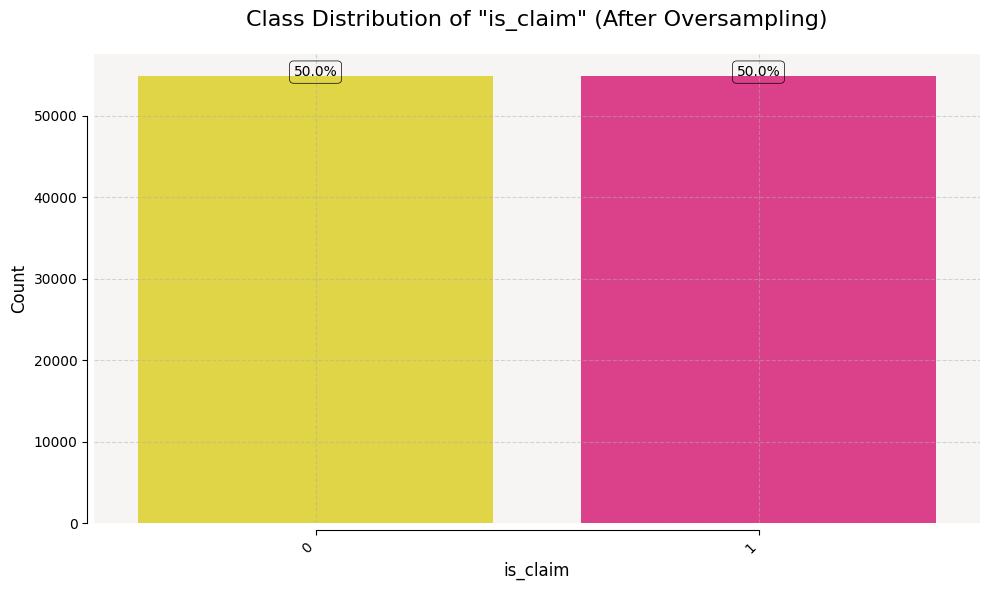

In [70]:
# Count plot for target variable after oversampling
create_count_plot(pd.DataFrame({'is_claim': y_resampled}), x_col='is_claim', hue_col=None, title='Class Distribution of "is_claim" (After Oversampling)')

In [71]:
# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

#Check for null valeus again
df_encoded.isnull().sum()

,0
policy_tenure,0
age_of_car,0
age_of_policyholder,0
population_density,0
make,0
airbags,0
is_esc,0
is_adjustable_steering,0
is_tpms,0
is_parking_sensors,0


In [73]:
# Splitting the data into a training set and a testing set
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

In [74]:
# Print the shapes of the resulting sets to verify the split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (87750, 110)
X_test shape: (21938, 110)
y_train shape: (87750,)
y_test shape: (21938,)


In [75]:
# Initialize the Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Fit the classifier to the training data
rf_classifier.fit(X_train, y_train)

#Make predictions on the test data
y_pred = rf_classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9062357553104202
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     11092
           1       0.90      0.91      0.91     10846

    accuracy                           0.91     21938
   macro avg       0.91      0.91      0.91     21938
weighted avg       0.91      0.91      0.91     21938

Confusion Matrix:
[[9958 1134]
 [ 923 9923]]


================================================================================
MACHINE LEARNING PIPELINE: IN-DEPTH TECHNICAL SUMMARY
================================================================================

1. EXPLORATORY DATA ANALYSIS (EDA) & SANITY CHECKS
   - What we did: Inspected distributions, checked ranges, and mapped out univariate
     and bivariate patterns using histograms, box plots, and bar charts.
   - Deep Dive: EDA acts as a reconnaissance mission. Spotting outliers early prevents
     anomalous data points from skewing mathematical weights during model training.

2. HANDLING MISSING VALUES & DATA HYGIENE
   - What we did: Ran null checks (isnull().sum()) and expanded Pandas display
     options to ensure zero blank or NaN cells existed in the dataframe.
   - Deep Dive: Machine learning algorithms are linear algebra equations. Encountering
     missing values causes matrix multiplications to break down and throw execution errors.

3. FEATURE ENCODING (BINARY MAPPING & ONE-HOT ENCODING)
   - What we did: Mapped affirmative text ("Yes"/"No") to integers (1/0) and
     transformed categorical text columns (like fuel_type) using One-Hot Encoding (pd.get_dummies).
   - Deep Dive: Computers require numerical input. One-hot encoding expands categories
     into separate binary columns, avoiding false numerical rankings (e.g., Petrol = 1 vs CNG = 3).

4. DROPPING NON-PREDICTIVE FEATURES (policy_id)
   - What we did: Dropped unique tracking identifiers like policy_id from the feature set.
   - Deep Dive: Unique IDs have zero predictive value relative to the target. Complex
     models can easily memorize them, leading to overfitting and poor generalization.

5. SEPARATING FEATURES (X) AND TARGET (y)
   - What we did: Sliced the dataframe into independent variables (X, the clues)
     and the dependent target variable (y, the answer key).
   - Deep Dive: Enforces a strict separation of inputs and outputs during supervised
     learning, preventing data leakage and forcing the model to learn true mapping functions.

6. RESOLVING CLASS IMBALANCE WITH SMOTE
   - What we did: Initialized SMOTE and synthetically oversampled the minority class
     (is_claim = 1), balancing the dataset to a 50/50 split and adding over 51,000 synthetic rows.
   - Deep Dive: Combats the Accuracy Paradox. Rather than blind duplication (which
     causes overfitting), SMOTE interpolates brand-new, realistic synthetic data points
     using neighborhood calculations, ensuring the model learns the decision boundary equally.
================================================================================